### 4.2 Elastic Net — regularized, direct multi-horizon

$$\hat\beta_h = \operatorname*{argmin}_{\beta}\ \frac{1}{2n}\lVert y_{t+h}-X_t\beta\rVert_2^2
+ \alpha\rho\lVert\beta\rVert_1 + \alpha\tfrac{1-\rho}{2}\lVert\beta\rVert_2^2 ,\qquad h=1,\dots,8$$

One fitted $\beta_h$ *per horizon* — not one model rolled forward eight times. $\alpha$ and
$\rho$ (`l1_ratio`) are chosen by `GridSearchCV` over chronological `TimeSeriesSplit` folds,
scaler refit inside each fold. The $\ell_1$ term can zero out a weak macro feature entirely;
the $\ell_2$ term keeps correlated survivors from cancelling each other out.

**This argmin does not minimize RMSE, deliberately.** The `(1/2n)‖·‖²` term is proportional
to MSE, but the $\ell_1$/$\ell_2$ penalty terms bias $\hat\beta_h$ *away* from the
MSE-minimizing (OLS) solution on purpose — that trade-off is the entire mechanism of
regularization: accept worse in-sample fit for coefficients that generalize better
out-of-sample. `GridSearchCV`'s own `scoring="neg_mean_squared_error"` isn't RMSE either,
though for *ranking* candidate `(α, l1_ratio)` pairs it's equivalent — RMSE = √MSE, and
√ is monotonic, so MSE and RMSE always pick the same winner. The project's headline RMSE
success criterion ([§1](../01_business_understanding)) only re-enters once $\hat\beta_h$ is fixed: it's the walk-forward,
out-of-sample metric used in [§5 Evaluation](../05_evaluation) to compare Elastic Net's *resulting forecasts*
against SARIMA, Ensemble, seasonal-naive, and the RBA — not a claim that every family's own
training loss literally is RMSE.

*Source: `src/models/elastic_net.py`*

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

Headline, horizon 1: alpha=0.1668  l1_ratio=0.70  (6 of 11 features shrunk to exactly zero)


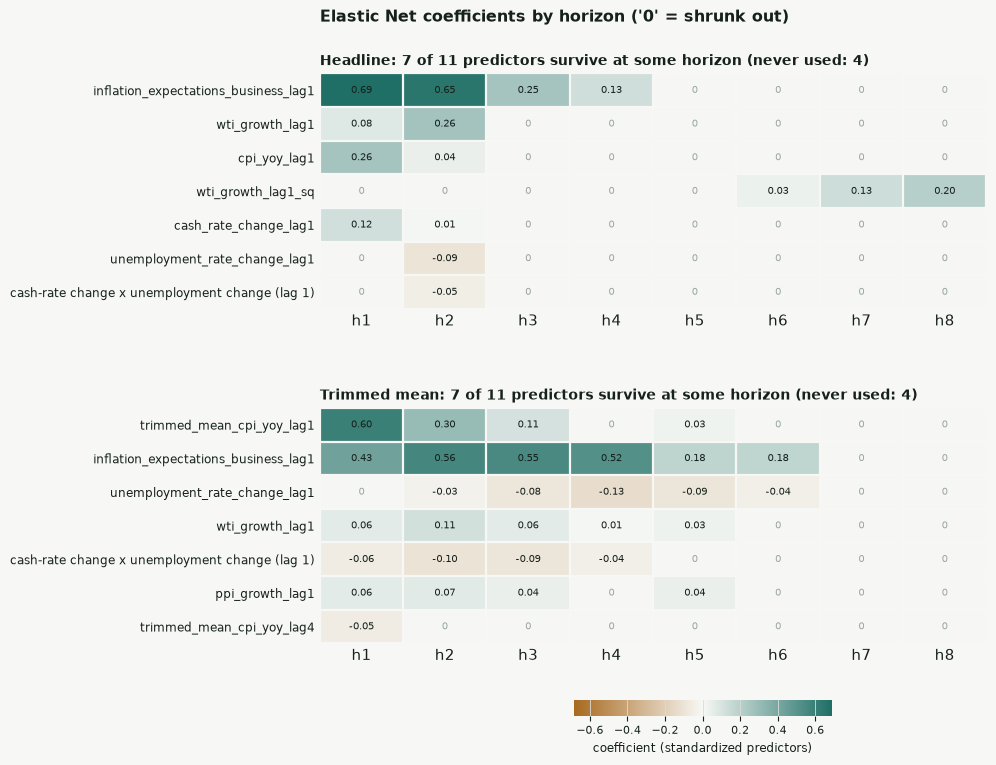

In [2]:
from matplotlib.colors import LinearSegmentedColormap

coefs = pd.read_csv(PROJECT_ROOT / "reports/elastic_net_coefficients.csv")
h1 = coefs[coefs["horizon"] == 1]
print(f"Headline, horizon 1: alpha={h1['selected_alpha'].iloc[0]:.4f}  l1_ratio={h1['selected_l1_ratio'].iloc[0]:.2f}"
      f"  ({(h1['coef'] == 0).sum()} of {len(h1)} features shrunk to exactly zero)")

DIVERGING = LinearSegmentedColormap.from_list("amber_teal", [HIGHLIGHT, PAPER, ACCENT])
SHORT = {"cash_rate_change_lag1_x_unemployment_rate_change_lag1": "cash-rate change x unemployment change (lag 1)"}
targets = [
    ("Headline", "elastic_net_coefficients.csv"),
    ("Trimmed mean", "elastic_net_coefficients_trimmed_mean.csv"),
]
frames = {}
for label, fname in targets:
    c = pd.read_csv(PROJECT_ROOT / "reports" / fname)
    wide = c.pivot(index="feature", columns="horizon", values="coef")
    wide = wide.where(wide.abs() >= 0.005, 0.0)          # below 0.005 rounds to zero at this scale
    wide = wide.loc[wide.abs().max(axis=1).sort_values(ascending=False).index]
    frames[label] = wide
vmax = max(w.abs().to_numpy().max() for w in frames.values())

heights = [max(len(w[(w != 0).any(axis=1)]), 1) for w in frames.values()]
fig, axes = plt.subplots(2, 1, figsize=(8.6, 0.4 * sum(heights) + 2.0), gridspec_kw={"height_ratios": heights})
for ax, (label, wide) in zip(axes, frames.items()):
    kept = wide[(wide != 0).any(axis=1)]
    dropped = [f for f in wide.index if f not in kept.index]
    ax.imshow(kept.to_numpy(), cmap=DIVERGING, vmin=-vmax, vmax=vmax, aspect="auto")
    for (i, j), v in np.ndenumerate(kept.to_numpy()):
        if v == 0:
            ax.text(j, i, "0", ha="center", va="center", fontsize=7.5, color=MUTED)
        else:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, color=INK)
    ax.set_xticks(range(kept.shape[1]), [f"h{h}" for h in kept.columns])
    ax.set_yticks(range(len(kept)), [SHORT.get(f, f) for f in kept.index], fontsize=8.3)
    ax.set_xticks(np.arange(-0.5, kept.shape[1]), minor=True)
    ax.set_yticks(np.arange(-0.5, len(kept)), minor=True)
    ax.grid(which="minor", color=PAPER, linewidth=1.6)
    ax.grid(which="major", visible=False)
    ax.tick_params(which="both", length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    n_zero_all = len(dropped)
    ax.set_title(f"{label}: {len(kept)} of {len(wide)} predictors survive at some horizon"
                 + (f" (never used: {n_zero_all})" if n_zero_all else ""),
                 loc="left", fontsize=10, fontweight="bold")
sm = plt.cm.ScalarMappable(cmap=DIVERGING, norm=plt.Normalize(-vmax, vmax))
fig.subplots_adjust(hspace=0.42, bottom=0.13)
cb = fig.colorbar(sm, cax=fig.add_axes([0.42, 0.035, 0.3, 0.02]), orientation="horizontal")
cb.set_label("coefficient (standardized predictors)", fontsize=8.5)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8)
axes[0].text(0, 1.22, "Elastic Net coefficients by horizon ('0' = shrunk out)", transform=axes[0].transAxes,
             fontsize=11.5, fontweight="bold")
plt.show()

#### Explained, step by step

- Read $\operatorname*{argmin}_\beta [\ldots]$ as "find the coefficient vector $\beta$ that makes the bracketed expression as small as possible."
- $\lVert y_{t+h}-X_t\beta\rVert_2^2$ is the **sum of squared prediction errors** — same idea as RMSE, but not square-rooted or averaged the same way — using today's macro features $X_t$ (unemployment, cash rate, producer prices, etc.) to predict the CPI value $h$ quarters ahead, $y_{t+h}$. Dividing by $2n$ is a scaling convention that simplifies the calculus; it doesn't change which $\beta$ wins.
- $\lVert\beta\rVert_1$ is the sum of the *absolute values* of the coefficients (the **L1 penalty**, or Lasso term). Adding this means every nonzero coefficient "costs" something, so the optimizer will happily set a weak feature's coefficient to *exactly* zero — automatic feature selection.
- $\lVert\beta\rVert_2^2$ is the sum of the *squared* coefficients (the **L2 penalty**, or Ridge term). It discourages any single coefficient from growing too large, and specifically helps when two macro features are correlated (e.g. oil prices and producer prices) — L2 tends to spread the credit between them rather than arbitrarily picking one.
- $\alpha$ controls the overall strength of both penalties; $\rho$ (`l1_ratio` in the code) controls the mix between L1 and Ridge, from $\rho=0$ (pure Ridge) to $\rho=1$ (pure Lasso). Both are chosen automatically via a grid search over chronological `TimeSeriesSplit` folds, so the model is never validated on data from before its own training window.
- A **separate $\hat\beta_h$ is fitted for every horizon** $h=1,\dots,8$ — eight independent models, not one model iterated forward eight times — so the horizon-4 model can lean on entirely different features than the horizon-1 model.
- Why not minimize RMSE directly: the $\frac{1}{2n}\lVert\cdot\rVert_2^2$ term alone would be minimized by plain OLS. Adding the L1/L2 penalties deliberately *pulls the solution away* from that OLS optimum — trading a little in-sample fit for a model that generalizes better out-of-sample. RMSE only re-enters later, in Evaluation, to judge the *resulting forecasts* — not what's being minimized during training.

**Why the feature sets are similar but not identical — and why regularize at all.** Headline
and trimmed-mean Elastic Net each use 11 predictors with the same structure, differing in two
terms (`ppi_growth_lag2` and `ppi_growth_lag2_sq` for headline; `ppi_growth_lag1` and
`commodity_growth_lag1_sq` for trimmed mean), because exogenous screening surfaces different
strongest signals for each target:
headline's are `inflation_expectations_business_lag1` (corr 0.7407, Granger p=0.0000),
`ppi_growth_lag2` (corr 0.5556, p=0.0066), and `cash_rate_lag2`/`cash_rate_change_lag1`
(corr 0.5112, p=0.0001/0.0000); trimmed-mean's are different: `commodity_growth_lag1`
(corr 0.3226, p=0.0360), `wti_growth_lag1` (corr up to 0.3039, p=0.0330), and
`brent_growth_lag1` (corr 0.3088, p=0.0372, a shorter-sample alternative). The trimmed-mean
block also keeps the inflation-expectations, cash-rate and unemployment terms even though the
screen ranks them weaker for that target: an earlier oil/commodity-only version (7 predictors)
shrank to a constant at horizons 5–8, and restoring them lowered walk-forward RMSE at every
horizon, so the penalty is left to decide how much weight they deserve. Regularizing at
all — rather than fitting an unrestricted regression — is itself justified by measured,
if moderate, multicollinearity among the CPI-lag features that survive screening:
`trimmed_mean_cpi_yoy_lag1` has VIF=3.427, `cpi_yoy_lag1` VIF=2.490, and `cpi_yoy_lag4`
VIF=1.854 — all under the conventional VIF=10 flag, but not negligible, which is exactly
the situation the $\ell_2$ term above is designed to handle.

*Source: [Appendix §15 — Documented Limitations](../appendix_eda/15_documented_limitations) (screening), [Appendix §8 — Multicollinearity And VIF](../appendix_eda/08_multicollinearity_vif) (VIF)*